# NLP processing

In [2]:
import numpy as np
import pandas as pd
import nltk
import jieba
from sudachipy import tokenizer
from sudachipy import dictionary
import MeCab
from mlask import MLAsk


import re
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats
from scipy.stats import skew, kurtosis, mannwhitneyu


In [91]:
# import data

jp = pd.read_csv('data/jp.csv')

en = pd.read_csv('data/en.csv')

cn = pd.read_csv('data/cn.csv')



In [92]:
# read NRC emotion lexicon - available in multiple languages through google translate 

nrc = pd.read_csv('data/NRC-Emotion-Lexicon-v0.92-InManyLanguages-web.csv')


In [93]:
nrc = nrc[['English Word', 
                   'Chinese (simplified) Translation (Google Translate)',
                   'Japanese Translation (Google Translate)',
                   'Positive', 
                   'Negative', 
                   'Anger',
                   'Anticipation', 
                   'Disgust', 
                   'Fear', 
                   'Joy', 
                   'Sadness', 
                   'Surprise',
                   'Trust'
                   ]]
                

In [94]:
en.head()

,label,merged_text
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
1,0,Did they post their votes for Hillary already?
2,0,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
3,1,"Bobby Jindal, raised Hindu, uses story of Chri..."
4,0,SATAN 2: Russia unvelis an image of its terrif...


# Clean & Tokenize - ENG

In [95]:
en = en[['label', 'merged_text']]

# removes url, punctuations, converts to lower-case. 
def clean_for_emotion(text):
    import re
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    return text

en['cleaned_text'] = en['merged_text'].apply(clean_for_emotion)

# remove punctuations while preserving some, then tokenize 
from nltk.tokenize import word_tokenize

en['tokenized'] = en['cleaned_text'].apply(lambda x: re.findall(r"\b\w+(?:'\w+)?\b", x))

en.head()

,label,merged_text,cleaned_text,tokenized
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,law enforcement on high alert following threat...,"[law, enforcement, on, high, alert, following,..."
1,0,Did they post their votes for Hillary already?,did they post their votes for hillary already?,"[did, they, post, their, votes, for, hillary, ..."
2,0,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,unbelievable! obama’s attorney general says mo...,"[unbelievable, obama, s, attorney, general, sa..."
3,1,"Bobby Jindal, raised Hindu, uses story of Chri...","bobby jindal, raised hindu, uses story of chri...","[bobby, jindal, raised, hindu, uses, story, of..."
4,0,SATAN 2: Russia unvelis an image of its terrif...,satan 2: russia unvelis an image of its terrif...,"[satan, 2, russia, unvelis, an, image, of, its..."


In [96]:
print(en)

       label                                        merged_text  \
0          0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1          0     Did they post their votes for Hillary already?   
2          0  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3          1  Bobby Jindal, raised Hindu, uses story of Chri...   
4          0  SATAN 2: Russia unvelis an image of its terrif...   
...      ...                                                ...   
72129      1  Russians steal research on Trump in hack of U....   
72130      0   WATCH: Giuliani Demands That Democrats Apolog...   
72131      1  Migrants Refuse To Leave Train At Refugee Camp...   
72132      1  Trump tussle gives unpopular Mexican leader mu...   
72133      0  Goldman Sachs Endorses Hillary Clinton For Pre...   

                                            cleaned_text  \
0      law enforcement on high alert following threat...   
1         did they post their votes for hillary already?   
2      unbeliev

# Clean & Tokenize - CN

In [97]:
cn = cn[['label', 'merged_text']]

# Clean URLs and remove punctuation
def clean_text_cn(text):
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    # Remove punctuation (both English and Chinese)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", "", text)  # remove all whitespace
    return text

cn['cleaned_text'] = cn['merged_text'].apply(clean_text_cn)

# Tokenize with jieba
cn['tokenized'] = cn['cleaned_text'].apply(jieba.lcut)

cn.head()


,label,merged_text,cleaned_text,tokenized
0,0,青少年妈妈明星珍妮尔·埃文斯的婚纱在这里售价2999美元 2023年3月23日 · 青少年妈...,青少年妈妈明星珍妮尔埃文斯的婚纱在这里售价2999美元2023年3月23日青少年妈妈明星Je...,"[青少年, 妈妈, 明星, 珍妮, 尔, 埃文斯, 的, 婚纱, 在, 这里, 售价, 29..."
1,0,凯莉·詹纳拒绝就《凯莉的一生》讨论泰加 2020年2月23日 · 2018年詹纳才20岁（她...,凯莉詹纳拒绝就凯莉的一生讨论泰加2020年2月23日2018年詹纳才20岁她在8月满21岁同...,"[凯莉, 詹纳, 拒绝, 就, 凯莉, 的, 一生, 讨论, 泰加, 2020, 年, 2,..."
2,0,奎因帕金斯 2023年3月30日 · 虎扑03月30日讯 今日步行者官方宣布，球队正式裁掉后...,奎因帕金斯2023年3月30日虎扑03月30日讯今日步行者官方宣布球队正式裁掉后卫特雷夫林奎...,"[奎因, 帕金斯, 2023, 年, 3, 月, 30, 日虎, 扑, 03, 月, 30,..."
3,0,席琳·迪翁向拉斯维加斯枪击案受害者捐赠音乐会收益 2021年11月10日 · 今年10月下旬...,席琳迪翁向拉斯维加斯枪击案受害者捐赠音乐会收益2021年11月10日今年10月下旬席琳迪翁亲...,"[席琳迪翁, 向, 拉斯维加斯, 枪击案, 受害者, 捐赠, 音乐会, 收益, 2021, ..."
4,0,Chris Evans、Millie Bobby Brown、Snoop Dogg等明星为被...,ChrisEvansMillieBobbyBrownSnoopDogg等明星为被欺负的学生K...,"[ChrisEvansMillieBobbyBrownSnoopDogg, 等, 明星, 为..."


# Clean & Tokenize - JP

In [98]:
# An Experimental Evaluation of Japanese Tokenizers for Sentiment-Based Text Classification - Sudachi as a tokenizer that works well

jp = jp[['label', 'merged_text']]

jp['cleaned_text'] = jp['merged_text'].apply(clean_text_cn)

tokenizer_obj = dictionary.Dictionary().create()

jp.head()

,label,merged_text,cleaned_text
0,0,朝日新聞など各社の報道によれば、宅配便最大手「ヤマト運輸」が日本郵政公社を相手取り、大手コン...,朝日新聞など各社の報道によれば宅配便最大手ヤマト運輸が日本郵政公社を相手取り大手コンビニエン...
1,1,11月5日の各社報道によると、諫早湾干拓事業は諫早海人（諫早湾の「海」）に囲まれる大洋に位置...,11月5日の各社報道によると諫早湾干拓事業は諫早海人諫早湾の海に囲まれる大洋に位置することか...
2,1,産経新聞、中日新聞によると、2004年から2005年まで、この大会による3年おきの開催を、2...,産経新聞中日新聞によると2004年から2005年までこの大会による3年おきの開催を2006年...
3,1,開催地のリオデジャネイロ市に対して、大会期間中のリオデジャネイロオリンピックに関する公式発表...,開催地のリオデジャネイロ市に対して大会期間中のリオデジャネイロオリンピックに関する公式発表は...
4,1,毎日新聞・時事通信によると、2006年2月13日には、グッドウィル・グッゲンハイム・アン・ハ...,毎日新聞時事通信によると2006年2月13日にはグッドウィルグッゲンハイムアンハルクを経営す...


In [99]:
mode = tokenizer.Tokenizer.SplitMode.C

jp['tokenized'] = jp['cleaned_text'].apply(lambda text: [m.surface() for m in tokenizer_obj.tokenize(text, mode)])

jp.head()

,label,merged_text,cleaned_text,tokenized
0,0,朝日新聞など各社の報道によれば、宅配便最大手「ヤマト運輸」が日本郵政公社を相手取り、大手コン...,朝日新聞など各社の報道によれば宅配便最大手ヤマト運輸が日本郵政公社を相手取り大手コンビニエン...,"[朝日新聞, など, 各社, の, 報道, に, よれ, ば, 宅配便, 最大手, ヤマト運..."
1,1,11月5日の各社報道によると、諫早湾干拓事業は諫早海人（諫早湾の「海」）に囲まれる大洋に位置...,11月5日の各社報道によると諫早湾干拓事業は諫早海人諫早湾の海に囲まれる大洋に位置することか...,"[11, 月, 5, 日, の, 各社, 報道, に, よる, と, 諫早湾, 干拓, 事業..."
2,1,産経新聞、中日新聞によると、2004年から2005年まで、この大会による3年おきの開催を、2...,産経新聞中日新聞によると2004年から2005年までこの大会による3年おきの開催を2006年...,"[産経新聞, 中日, 新聞, に, よる, と, 2004, 年, から, 2005, 年,..."
3,1,開催地のリオデジャネイロ市に対して、大会期間中のリオデジャネイロオリンピックに関する公式発表...,開催地のリオデジャネイロ市に対して大会期間中のリオデジャネイロオリンピックに関する公式発表は...,"[開催地, の, リオデジャネイロ, 市, に, 対し, て, 大会, 期間中, の, リオ..."
4,1,毎日新聞・時事通信によると、2006年2月13日には、グッドウィル・グッゲンハイム・アン・ハ...,毎日新聞時事通信によると2006年2月13日にはグッドウィルグッゲンハイムアンハルクを経営す...,"[毎日, 新聞, 時事, 通信, に, よる, と, 2006, 年, 2, 月, 13, ..."


In [100]:
type(jp['tokenized'].iloc[0])

list

# Emotion Detection 

looks up each token in the NRC dict, calculate a normalized emotion score for each news input.

In [101]:
nrc = nrc.rename(columns = {"English Word":'EN',
                      'Chinese (simplified) Translation (Google Translate)':'CN',
                      'Japanese Translation (Google Translate)':'JP'})
nrc.head()

,EN,CN,JP,Positive,Negative,Anger,Anticipation,Disgust,Fear,Joy,Sadness,Surprise,Trust
0,aback,吓了一跳,あっけ,0,0,0,0,0,0,0,0,0,0
1,abacus,算盘,そろばん,0,0,0,0,0,0,0,0,0,1
2,abandon,放弃,捨てます,0,1,0,0,0,1,0,1,0,0
3,abandoned,弃,放棄されました,0,1,1,0,0,1,0,1,0,0
4,abandonment,放弃,放棄,0,1,1,0,0,1,0,1,1,0


In [105]:
def checknull(df):
    df['cleaned_len'] = df['cleaned_text'].astype(str).str.strip().str.len()
    df['cleaned_empty'] = df['cleaned_len'] == 0

    print("Cleaned to empty:", df['cleaned_empty'].sum())

In [106]:
def checknulltoken(df):
    df['token_len'] = df['tokenized'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    df['token_empty'] = df['token_len'] == 0

    print("Empty token lists:", df['token_empty'].sum())

In [107]:
print("cn checknull: ", checknull(cn))
print("en checknull: ", checknull(en))
print("jp checknull: ", checknull(jp))

print("cn checknulltoken: ", checknulltoken(cn))
print("en checknulltoken: ", checknulltoken(en))
print("jp checknulltoken: ", checknulltoken(jp))

Cleaned to empty: 2
cn checknull:  None
Cleaned to empty: 9
en checknull:  None
Cleaned to empty: 0
jp checknull:  None
Empty token lists: 2
cn checknulltoken:  None
Empty token lists: 10
en checknulltoken:  None
Empty token lists: 0
jp checknulltoken:  None


In [108]:
en[en['token_empty']==True]

,label,merged_text,cleaned_text,tokenized,cleaned_len,cleaned_empty,token_len,token_empty
795,0,https://fedup.wpengine.com/wp-content/uploads/...,,[],0,True,0,True
8909,0,https://fedup.wpengine.com/wp-content/uploads/...,,[],0,True,0,True
14238,0,https://fedup.wpengine.com/wp-content/uploads/...,,[],0,True,0,True
26286,0,https://fedup.wpengine.com/wp-content/uploads/...,,[],0,True,0,True
27236,0,https://fedup.wpengine.com/wp-content/uploads/...,,[],0,True,0,True
31816,0,🙂,🙂,[],1,False,0,True
42774,0,https://100percentfedup.com/served-roy-moore-v...,,[],0,True,0,True
44862,0,https://100percentfedup.com/12-yr-old-black-co...,,[],0,True,0,True
52702,0,https://100percentfedup.com/video-hillary-aske...,,[],0,True,0,True
68385,0,https://fedup.wpengine.com/wp-content/uploads/...,,[],0,True,0,True


In [109]:
cn[cn['token_empty']==True]

,label,merged_text,cleaned_text,tokenized,cleaned_len,cleaned_empty,token_len,token_empty
12782,0,http://t.cn/8k5WWOm《夏洛的网》12大结局！感谢大家的坚持收听！[呵呵]...,,[],0,True,0,True
14053,0,http://t.cn/zjp1jpP我想请全国人民都来聚焦我们孩子的精神处境，我们当下的...,,[],0,True,0,True


In [110]:
# remove the empty rows from the table

def remove_empty(df):
    return df.loc[~df['token_empty']].copy()

In [111]:
cn_clean = remove_empty(cn)
en_clean = remove_empty(en)
jp_clean = remove_empty(jp)

In [112]:
EMOTIONS = ['Positive', 
            'Negative',
            'Anger',
            'Anticipation',
            'Disgust',
            'Fear',
            'Joy',
            'Sadness',
            'Surprise',
            'Trust']


LANGUAGES = {
    'English': (en_clean, 'EN'),           
    'Chinese': (cn_clean, 'CN'), 
    'Japanese': (jp_clean, 'JP'),          
}

# build lookup table
def build_lookup(lex_df, word_col):
    """Build {word: {emotion: score}} dict for fast lookup."""
    sub = lex_df.dropna(subset=[word_col]).drop_duplicates(subset=[word_col], keep='first').set_index(word_col)[EMOTIONS]
    return sub.to_dict('index')


In [113]:
# scoring tokens
def score_tokens(token_list, lookup):
    """
    Given a list of tokens and a lookup dict,
    return a dict of normalised emotion scores (per token).
    Normalising by article length reduces bias from longer articles.
    """
    counts = {e: 0 for e in EMOTIONS}
    for token in token_list:
        if token in lookup:
            for e in EMOTIONS:
                counts[e] += lookup[token][e]

    n = len(token_list)
    return {e: counts[e]/n for e in EMOTIONS}

# add emotions score

def add_emo_score(df, lang_col):
    """Parse tokenized_text and add one column per emotion."""
    lookup = build_lookup(nrc, lang_col)
    df = df.copy()
    scores = df['tokenized'].apply(lambda x: score_tokens(x, lookup))
    scores_df = pd.DataFrame(scores.tolist(), index = df.index)
    df = pd.concat([df.drop(columns = ['tokenized']), scores_df], axis = 1)
    return df 



In [114]:
# apply to three languages

scored = {}

for lang, (df, col) in LANGUAGES.items():
    scored[lang] = add_emo_score(df, col)

scored

{'English':        label                                        merged_text  \
 0          0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
 1          0     Did they post their votes for Hillary already?   
 2          0  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
 3          1  Bobby Jindal, raised Hindu, uses story of Chri...   
 4          0  SATAN 2: Russia unvelis an image of its terrif...   
 ...      ...                                                ...   
 72129      1  Russians steal research on Trump in hack of U....   
 72130      0   WATCH: Giuliani Demands That Democrats Apolog...   
 72131      1  Migrants Refuse To Leave Train At Refugee Camp...   
 72132      1  Trump tussle gives unpopular Mexican leader mu...   
 72133      0  Goldman Sachs Endorses Hillary Clinton For Pre...   
 
                                             cleaned_text  cleaned_len  \
 0      law enforcement on high alert following threat...         5180   
 1         did they pos

In [115]:
# aggregate tables 

agg_tables = {}
for lang, df in scored.items():
    real = df[df['label'] == 0]
    fake = df[df['label'] == 1]
    
    rows = []
    for emotion in EMOTIONS:
        rows.append({
            'emotion': emotion,
            'real_mean': real[emotion].mean(),
            'real_sem': real[emotion].sem(),
            'fake_mean': fake[emotion].mean(),
            'fake_sem': fake[emotion].sem(),
            'diff (fake-real)': fake[emotion].mean() - real[emotion].mean()
        })
    
    tbl = pd.DataFrame(rows).set_index('emotion')
    agg_tables[lang] = tbl
    print(f"\n── {lang} ──")
    print(tbl.round(5))


── English ──
              real_mean  real_sem  fake_mean  fake_sem  diff (fake-real)
emotion                                                                 
Positive        0.05339   0.00015    0.05858   0.00011           0.00519
Negative        0.03984   0.00013    0.03586   0.00010          -0.00398
Anger           0.02060   0.00009    0.01795   0.00007          -0.00265
Anticipation    0.02380   0.00010    0.02341   0.00007          -0.00039
Disgust         0.01199   0.00008    0.00816   0.00004          -0.00383
Fear            0.02626   0.00011    0.02497   0.00010          -0.00129
Joy             0.01595   0.00010    0.01454   0.00006          -0.00141
Sadness         0.01715   0.00008    0.01523   0.00006          -0.00192
Surprise        0.01776   0.00009    0.01511   0.00006          -0.00265
Trust           0.03915   0.00013    0.04705   0.00012           0.00790

── Chinese ──
              real_mean  real_sem  fake_mean  fake_sem  diff (fake-real)
emotion              

In [116]:
print(agg_tables['English'].head())

              real_mean  real_sem  fake_mean  fake_sem  diff (fake-real)
emotion                                                                 
Positive       0.053388  0.000146   0.058581  0.000113          0.005193
Negative       0.039839  0.000133   0.035858  0.000099         -0.003981
Anger          0.020604  0.000090   0.017951  0.000074         -0.002653
Anticipation   0.023801  0.000104   0.023409  0.000070         -0.000393
Disgust        0.011987  0.000076   0.008159  0.000043         -0.003827


# Lookup match rate for CN & JP 

In [117]:
lookup_cn = build_lookup(nrc, 'CN')

def match_rate(df, lookup):
    def pct(tokens):
        matched = sum(1 for t in tokens if t in lookup)
        return matched / len(tokens) if tokens else 0
    return df['tokenized'].apply(pct).describe()

print(match_rate(cn, lookup_cn))

count    15830.000000
mean         0.300635
std          0.093544
min          0.000000
25%          0.240000
50%          0.300000
75%          0.361702
max          0.800000
Name: tokenized, dtype: float64


In [118]:
print(match_rate(jp, build_lookup(nrc, 'JP')))

count    13316.000000
mean         0.189352
std          0.045283
min          0.000000
25%          0.160000
50%          0.186776
75%          0.214815
max          0.733691
Name: tokenized, dtype: float64


# visualization - emotion across languages, real vs. fake

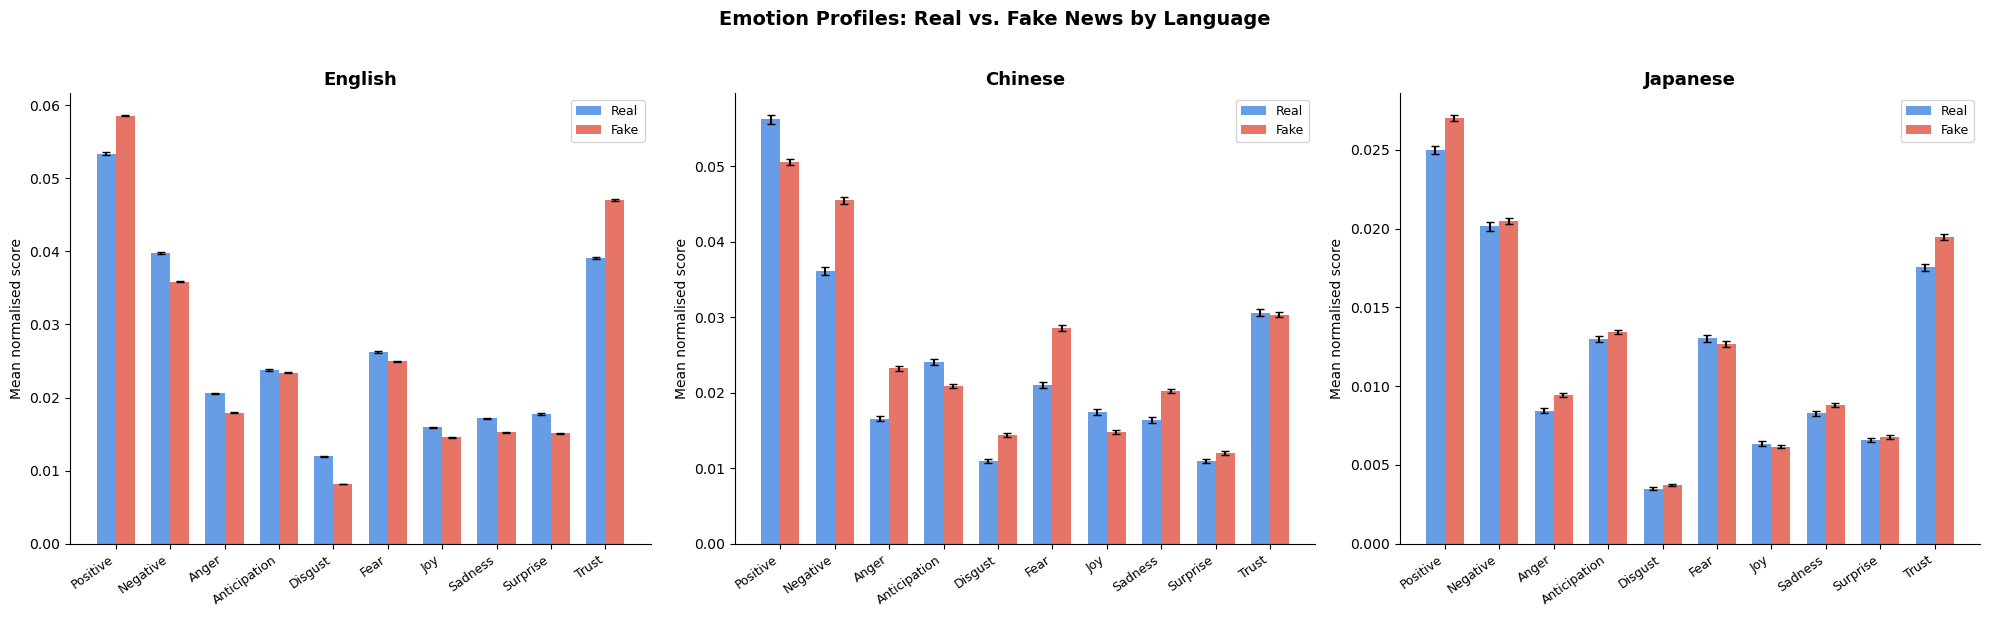

In [119]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

colors = {'real': '#4C8BE2', 'fake': '#E25C4C'}
x = np.arange(len(EMOTIONS))
width = 0.35

for ax, (lang, tbl) in zip(axes, agg_tables.items()):
    # bars
    bars_real = ax.bar(x - width/2, tbl['real_mean'], width,
                   yerr=tbl['real_sem'], capsize=3,
                   color=colors['real'], alpha=0.85, label='Real')
    bars_fake = ax.bar(x + width/2, tbl['fake_mean'], width,
                   yerr=tbl['fake_sem'], capsize=3,
                   color=colors['fake'], alpha=0.85, label='Fake')

    ax.set_title(lang, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(EMOTIONS, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('Mean normalised score')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Emotion Profiles: Real vs. Fake News by Language',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('emotion_barplot.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical Analyses

In [120]:
from scipy.stats import skew, kurtosis

for lang, df in scored.items():
    print(f"\n── {lang} ──")
    rows = []
    for emotion in EMOTIONS:
        for label, name in [(0, 'real'), (1, 'fake')]:
            vals = df[df['label'] == label][emotion]
            rows.append({
                'emotion': emotion,
                'group': name,
                'skewness': round(skew(vals), 3),
                'kurtosis': round(kurtosis(vals), 3),  # excess kurtosis, 0=normal
                'zero_pct': round((vals == 0).mean() * 100, 1)
            })
    print(pd.DataFrame(rows).to_string(index=False))


── English ──
     emotion group  skewness  kurtosis  zero_pct
    Positive  real     8.503   252.687       3.4
    Positive  fake     1.119     3.821       0.3
    Negative  real     5.661   132.716       4.3
    Negative  fake     0.854     1.870       2.4
       Anger  real     3.461    31.447       9.3
       Anger  fake     1.688     7.250       8.3
Anticipation  real    15.968   654.344       6.5
Anticipation  fake     1.572     7.832       3.4
     Disgust  real    14.915   705.295      15.2
     Disgust  fake     2.174     9.950      17.9
        Fear  real     3.349    38.357       6.9
        Fear  fake     1.469     4.567       5.5
         Joy  real    20.270   943.543      10.7
         Joy  fake     1.712     6.184       8.0
     Sadness  real     4.722    80.018      10.6
     Sadness  fake     1.816     7.167       9.5
    Surprise  real     3.879    44.383      11.0
    Surprise  fake     1.499     4.225       8.3
       Trust  real    11.070   378.673       4.7
     

C:\Users\acl13\AppData\Local\Temp\ipykernel_26412\4150972924.py:14: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\acl13\AppData\Local\Temp\ipykernel_26412\4150972924.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(EMOTIONS, rotation=35, ha='right')
C:\Users\acl13\AppData\Local\Temp\ipykernel_26412\4150972924.py:14: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\acl13\AppData\Local\Temp\ipykernel_26412\4150972924.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(EMOTIONS, rotation=35, ha='right')
C:\Users\acl13\AppData\Local\Temp\ipykernel_26412\

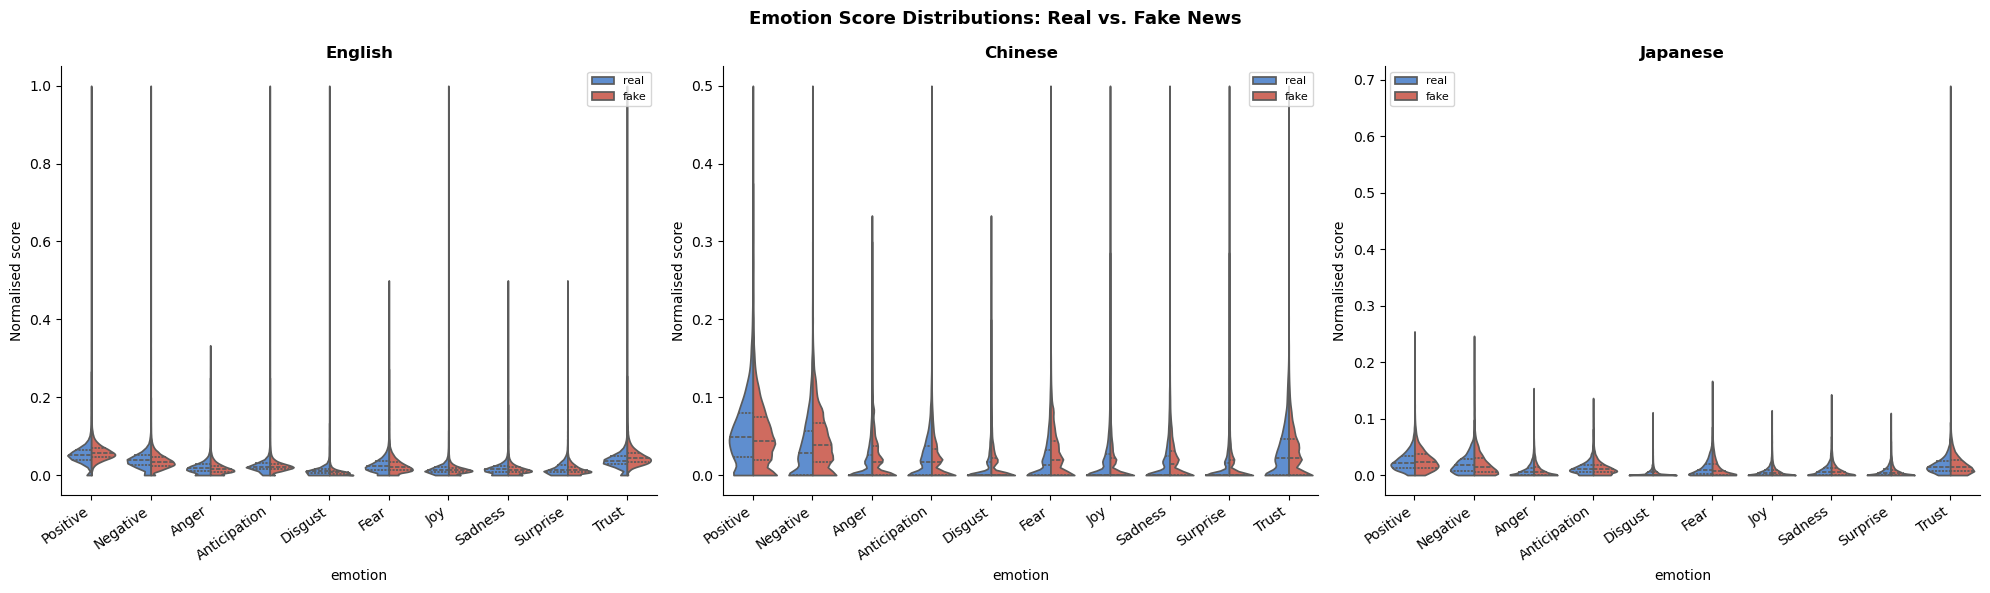

In [121]:
# violin plot that summarizes distributions

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (lang, df) in zip(axes, scored.items()):
    # melt to long format for seaborn
    long = df[['label'] + EMOTIONS].melt(
        id_vars='label',
        var_name='emotion',
        value_name='score'
    )
    long['group'] = long['label'].map({0: 'real', 1: 'fake'})

    sns.violinplot(
        data=long, x='emotion', y='score', hue='group',
        ax=ax, split=True, inner='quart',
        palette={'real': '#4C8BE2', 'fake': '#E25C4C'},
        scale='width', cut=0  # cut=0 stops violins extending below 0
    )
    ax.set_title(lang, fontweight='bold')
    ax.set_xticklabels(EMOTIONS, rotation=35, ha='right')
    ax.set_ylabel('Normalised score')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Emotion Score Distributions: Real vs. Fake News',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('emotion_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [122]:
# lack of normality rules out T-test
# conduct Mann-Whitney U test instead
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

stats_results = {}

for lang, df in scored.items():
    real = df[df['label'] == 0]
    fake = df[df['label'] == 1]
    
    rows = []
    for emotion in EMOTIONS:
        stat, p = mannwhitneyu(fake[emotion], real[emotion], alternative='two-sided')
        r = 1 - (2 * stat) / (len(fake) * len(real))
        rows.append({
            'emotion': emotion,
            'mean_real': real[emotion].mean(),
            'mean_fake': fake[emotion].mean(),
            'U_stat': stat,
            'p_value': p,
            'effect_r': round(r, 4)
        })
    
    lang_df = pd.DataFrame(rows)
    
    # FDR correction across 10 emotions within this language
    rejected, p_fdr, _, _ = multipletests(lang_df['p_value'], method='fdr_bh')
    lang_df['p_fdr'] = p_fdr
    lang_df['significant'] = rejected
    
    stats_results[lang] = lang_df.set_index('emotion')
    print(f"\n── {lang} ──")
    print(lang_df.set_index('emotion').round(5))



── English ──
              mean_real  mean_fake       U_stat  p_value  effect_r    p_fdr  \
emotion                                                                       
Positive        0.05339    0.05858  745558023.5  0.00000   -0.1475  0.00000   
Negative        0.03984    0.03586  583570662.0  0.00000    0.1018  0.00000   
Anger           0.02060    0.01795  585886864.0  0.00000    0.0982  0.00000   
Anticipation    0.02380    0.02341  657189806.0  0.00735   -0.0115  0.00735   
Disgust         0.01199    0.00816  515963814.5  0.00000    0.2058  0.00000   
Fear            0.02626    0.02497  625105518.5  0.00000    0.0379  0.00000   
Joy             0.01595    0.01454  634120510.0  0.00000    0.0240  0.00000   
Sadness         0.01715    0.01523  600191043.0  0.00000    0.0762  0.00000   
Surprise        0.01776    0.01511  611963354.0  0.00000    0.0581  0.00000   
Trust           0.03915    0.04705  789954233.5  0.00000   -0.2159  0.00000   

              significant  
emotion 

In [123]:
en_clean.to_csv('data/en_clean.csv', index = False)
cn_clean.to_csv('data/cn_clean.csv', index = False)
jp_clean.to_csv('data/jp_clean.csv', index = False)

# REDO THESE!!! THE RESULTS HAVE BEEN UPDATED AFTER MORE RIGOROUS CLEANING!

EN: all significant. 
Effect sizes large to small: (neglected the ones smaller than .1)
* disgust (.21)
* trust (-.18)
* positive (-.11)
* negative (.11)
* anger (.1)

CN: all significant.
Effect sizes large to small: 
* anticipation (.13)
* joy (.12)
* negative (-.12)
* positive (.10)

JP: all significant except anger & trust
Effect sizes large to small:
* fear (.08) 
the rest are too small. 
